# Import data

In [1]:
#!/bin/bash
!curl -L -o pediatric-chest-xray-pneumonia-balanced-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/yusufmurtaza01/pediatric-chest-xray-pneumonia-balanced-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1703M  100 1703M    0     0   113M      0  0:00:14  0:00:14 --:--:--  116M


In [2]:
import zipfile, io, random, numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Load dataset from zip

In [3]:
class ZipXrayDataset(Dataset):
    """Streams images directly from the zip file — no extraction needed."""

    def __init__(self, zip_path, transform=None):
        self.zip_path = zip_path
        self.transform = transform
        self.samples = []  # (filename, label)

        with zipfile.ZipFile(zip_path, "r") as zf:
            for name in zf.namelist():
                if not name.lower().endswith((".jpeg", ".jpg", ".png")):
                    continue
                if name.startswith("NORMAL/"):
                    self.samples.append((name, 0))
                elif name.startswith("PNEUMONIA/"):
                    self.samples.append((name, 1))

        print(f"Loaded {len(self.samples)} images  |  "
              f"NORMAL: {sum(1 for _, l in self.samples if l == 0)}  |  "
              f"PNEUMONIA: {sum(1 for _, l in self.samples if l == 1)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        with zipfile.ZipFile(self.zip_path, "r") as zf:
            img = Image.open(io.BytesIO(zf.read(fname))).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

In [4]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

full_dataset = ZipXrayDataset("pediatric-chest-xray-pneumonia-balanced-dataset.zip")

# 80 / 10 / 10 split
n = len(full_dataset)
n_train = int(0.8 * n)
n_val = int(0.1 * n)
n_test = n - n_train - n_val

torch.manual_seed(42)
train_ds, val_ds, test_ds = random_split(full_dataset, [n_train, n_val, n_test])

# Apply different transforms to each split
train_ds.dataset = ZipXrayDataset("pediatric-chest-xray-pneumonia-balanced-dataset.zip", transform=train_transform)
val_ds.dataset   = ZipXrayDataset("pediatric-chest-xray-pneumonia-balanced-dataset.zip", transform=val_transform)
test_ds.dataset  = ZipXrayDataset("pediatric-chest-xray-pneumonia-balanced-dataset.zip", transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}  |  Test: {len(test_ds)}")

Loaded 8530 images  |  NORMAL: 4265  |  PNEUMONIA: 4265
Loaded 8530 images  |  NORMAL: 4265  |  PNEUMONIA: 4265
Loaded 8530 images  |  NORMAL: 4265  |  PNEUMONIA: 4265
Loaded 8530 images  |  NORMAL: 4265  |  PNEUMONIA: 4265
Train: 6824  |  Val: 853  |  Test: 853


# Hyperparameter Sensitivity Analysis
Vary 5 parameters one at a time (holding others at baseline) and compare val accuracy:
1. **Learning Rate**: 1e-3, **1e-4**, 1e-5
2. **Dropout**: 0.1, **0.3**, 0.5
3. **Batch Size**: 16, **32**, 64
4. **Unfreeze Depth**: layer4 only, layer3+4, all layers
5. **Optimizer**: **Adam**, SGD (momentum=0.9)

Baseline values in **bold**.

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models

def build_model(dropout=0.3, unfreeze="layer4"):
    """Build a MobileNetV2 with the given dropout and unfreeze strategy."""
    m = models.mobilenet_v2(pretrained=True)
    for param in m.parameters():
        param.requires_grad = False

    # Unfreeze the classifier parameters by default, as it will be replaced/fine-tuned
    for param in m.classifier.parameters():
        param.requires_grad = True

    if unfreeze == "layer4":
        # Unfreeze the last few blocks of the features extractor
        for param in m.features[14:].parameters():
            param.requires_grad = True
    elif unfreeze == "layer3+4":
        # Unfreeze more blocks
        for param in m.features[7:].parameters():
            param.requires_grad = True
    elif unfreeze == "all":
        for param in m.parameters():
            param.requires_grad = True

    # Replace the entire classifier with the new head (Dropout + Linear)
    m.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(m.classifier[1].in_features, 1),
    )
    return m.to(device)


def train_and_evaluate(config, num_epochs=10):
    """Train with a given config dict and return history + test accuracy."""
    lr = config.get("lr", 1e-4)
    dropout = config.get("dropout", 0.3)
    batch_size = config.get("batch_size", 32)
    unfreeze = config.get("unfreeze", "layer4")
    opt_name = config.get("optimizer", "adam")

    pin = device.type == "cuda"
    nw = 4 if pin else 0

    # Rebuild data loaders with the specified batch size
    tl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                    num_workers=nw, pin_memory=pin)
    vl = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                    num_workers=nw, pin_memory=pin)
    te = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                    num_workers=nw, pin_memory=pin)

    m = build_model(dropout=dropout, unfreeze=unfreeze)
    crit = nn.BCEWithLogitsLoss()

    trainable = filter(lambda p: p.requires_grad, m.parameters())
    if opt_name == "adam":
        opt = optim.Adam(trainable, lr=lr)
    else:
        opt = optim.SGD(trainable, lr=lr, momentum=0.9)

    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        m.train()
        rl, cor, tot = 0.0, 0, 0
        for imgs, labels in tl:
            imgs = imgs.to(device, non_blocking=pin)
            labels = labels.float().to(device, non_blocking=pin)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = m(imgs).squeeze(1)
                loss = crit(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            rl += loss.item() * imgs.size(0)
            cor += ((torch.sigmoid(logits) > 0.5).long() == labels.long()).sum().item()
            tot += imgs.size(0)
        hist["train_loss"].append(rl / tot)
        hist["train_acc"].append(cor / tot)

        m.eval()
        rl, cor, tot = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in vl:
                imgs = imgs.to(device, non_blocking=pin)
                labels = labels.float().to(device, non_blocking=pin)
                with torch.amp.autocast("cuda", enabled=use_amp):
                    logits = m(imgs).squeeze(1)
                    loss = crit(logits, labels)
                rl += loss.item() * imgs.size(0)
                cor += ((torch.sigmoid(logits) > 0.5).long() == labels.long()).sum().item()
                tot += imgs.size(0)
        hist["val_loss"].append(rl / tot)
        hist["val_acc"].append(cor / tot)

        print(f"       Epoch {epoch+1}/{num_epochs}  "
              f"train_acc={hist['train_acc'][-1]:.4f}  "
              f"val_acc={hist['val_acc'][-1]:.4f}", flush=True)

    # Test accuracy
    m.eval()
    cor, tot = 0, 0
    with torch.no_grad():
        for imgs, labels in te:
            imgs = imgs.to(device, non_blocking=pin)
            logits = m(imgs).squeeze(1)
            preds = (torch.sigmoid(logits) > 0.5).long().cpu()
            cor += (preds == labels).sum().item()
            tot += labels.size(0)
    test_acc = cor / tot

    return hist, test_acc

print("Helper functions defined.")

Helper functions defined.


In [6]:
# Define experiments: vary one param at a time, keep others at baseline
import torch # Added this line
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu") # Added this line

experiments = {
    "Learning Rate": [
        {"label": "lr=1e-4 (baseline)", "lr": 1e-4},
        {"label": "lr=1e-5", "lr": 1e-5},
    ],
    "Dropout": [
        {"label": "drop=0.3 (baseline)", "dropout": 0.3},
        {"label": "drop=0.5", "dropout": 0.5},
    ],
    "Batch Size": [
        {"label": "bs=32 (baseline)", "batch_size": 32},
        {"label": "bs=64", "batch_size": 64},
    ],
    "Unfreeze Depth": [
        {"label": "layer4 only (baseline)", "unfreeze": "layer4"},
        {"label": "all layers", "unfreeze": "all"},
    ],
    "Optimizer": [
        {"label": "Adam (baseline)", "optimizer": "adam"},
        {"label": "SGD (mom=0.9)", "optimizer": "sgd"},
    ],
}

# --- Deduplicate: collect unique configs, train each only once ---
def _config_key(cfg):
    """Hashable key from the non-label parts of a config."""
    return tuple(sorted((k, v) for k, v in cfg.items() if k != "label"))

unique_configs = {}  # key -> config dict (without label)
label_to_key = {}    # (exp_name, label) -> key

for exp_name, configs in experiments.items():
    for cfg in configs:
        key = _config_key(cfg)
        if key not in unique_configs:
            unique_configs[key] = {k: v for k, v in cfg.items() if k != "label"}
        label_to_key[(exp_name, cfg["label"])] = key

print(f"Total experiment slots: {sum(len(c) for c in experiments.values())}")
print(f"Unique configs to train: {len(unique_configs)}")

# Train each unique config once
trained = {}  # key -> (hist, test_acc)
for i, (key, cfg) in enumerate(unique_configs.items(), 1):
    print(f"\n{'='*60}", flush=True)
    print(f"  Config {i}/{len(unique_configs)}: {dict(cfg)}", flush=True)
    print(f"{'='*60}", flush=True)
    hist, test_acc = train_and_evaluate(cfg, num_epochs=10)
    best_val = max(hist["val_acc"])
    print(f"  Best val acc: {best_val:.4f}  |  Test acc: {test_acc:.4f}", flush=True)
    trained[key] = (hist, test_acc)

# Reassemble results in the original experiment structure
results = {}
for exp_name, configs in experiments.items():
    results[exp_name] = []
    for cfg in configs:
        key = label_to_key[(exp_name, cfg["label"])]
        hist, test_acc = trained[key]
        results[exp_name].append((cfg["label"], hist, test_acc))

print("\n\nAll experiments complete!")


Total experiment slots: 10
Unique configs to train: 10

  Config 1/10: {'lr': 0.0001}
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 13.6M/13.6M [00:00<00:00, 170MB/s]


       Epoch 1/10  train_acc=0.9452  val_acc=0.9601
       Epoch 2/10  train_acc=0.9710  val_acc=0.9683
       Epoch 3/10  train_acc=0.9754  val_acc=0.9672
       Epoch 4/10  train_acc=0.9799  val_acc=0.9683
       Epoch 5/10  train_acc=0.9834  val_acc=0.9730
       Epoch 6/10  train_acc=0.9812  val_acc=0.9707
       Epoch 7/10  train_acc=0.9827  val_acc=0.9707
       Epoch 8/10  train_acc=0.9875  val_acc=0.9754
       Epoch 9/10  train_acc=0.9875  val_acc=0.9719
       Epoch 10/10  train_acc=0.9896  val_acc=0.9789
  Best val acc: 0.9789  |  Test acc: 0.9789

  Config 2/10: {'lr': 1e-05}
       Epoch 1/10  train_acc=0.8614  val_acc=0.9402
       Epoch 2/10  train_acc=0.9445  val_acc=0.9519
       Epoch 3/10  train_acc=0.9581  val_acc=0.9578
       Epoch 4/10  train_acc=0.9629  val_acc=0.9601
       Epoch 5/10  train_acc=0.9642  val_acc=0.9613
       Epoch 6/10  train_acc=0.9670  val_acc=0.9601
       Epoch 7/10  train_acc=0.9713  val_acc=0.9660
       Epoch 8/10  train_acc=0.9711  val_

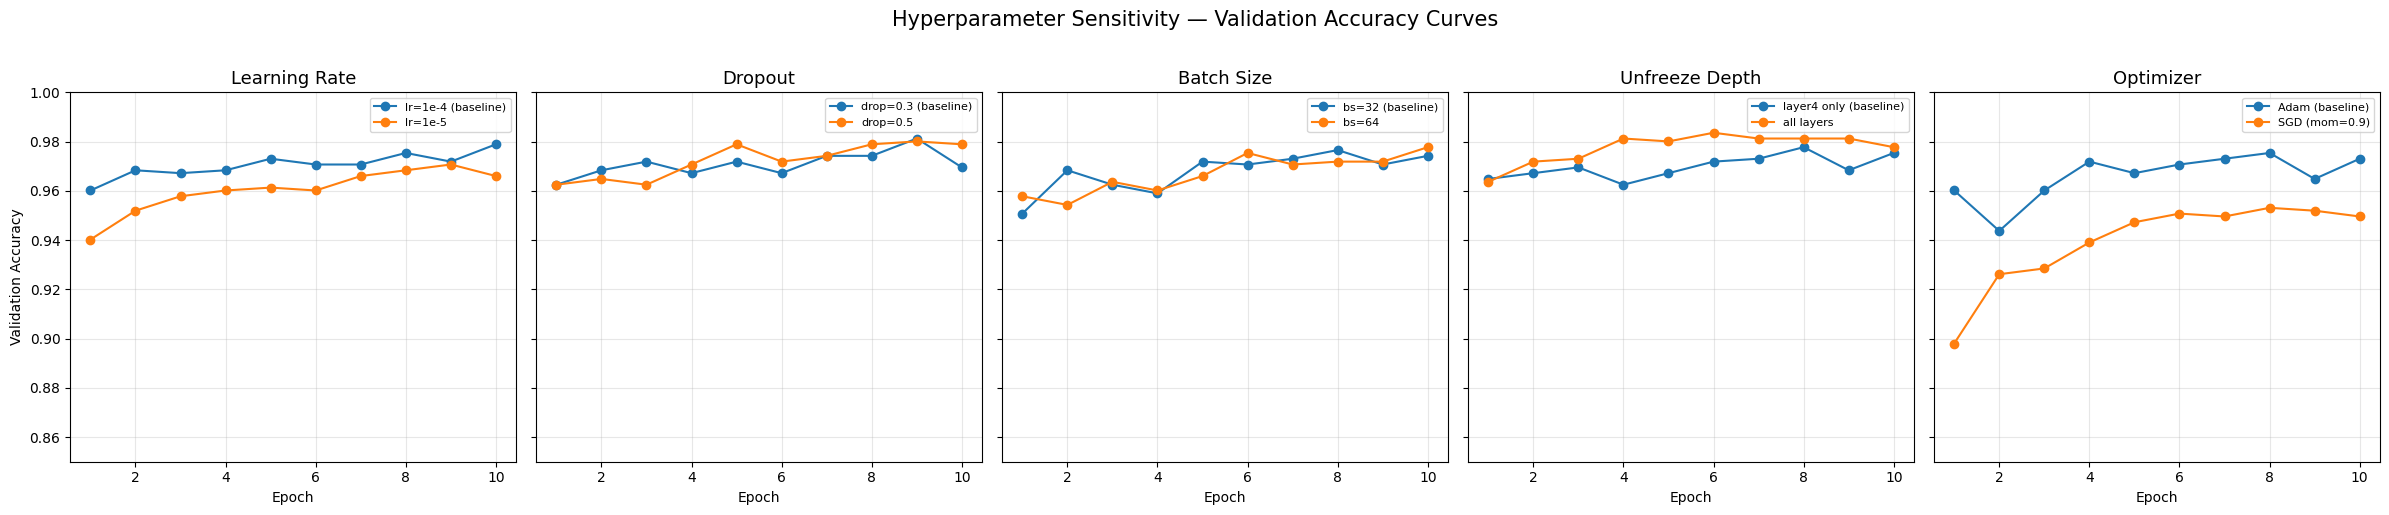

In [7]:
# Plot val accuracy curves for each experiment (side by side)
fig, axes = plt.subplots(1, 5, figsize=(24, 5), sharey=True)

for ax, (exp_name, runs) in zip(axes, results.items()):
    for label, hist, test_acc in runs:
        ax.plot(range(1, 11), hist["val_acc"], marker="o", label=label)
    ax.set_title(exp_name, fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylim(0.85, 1.0)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Validation Accuracy")
plt.suptitle("Hyperparameter Sensitivity — Validation Accuracy Curves", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

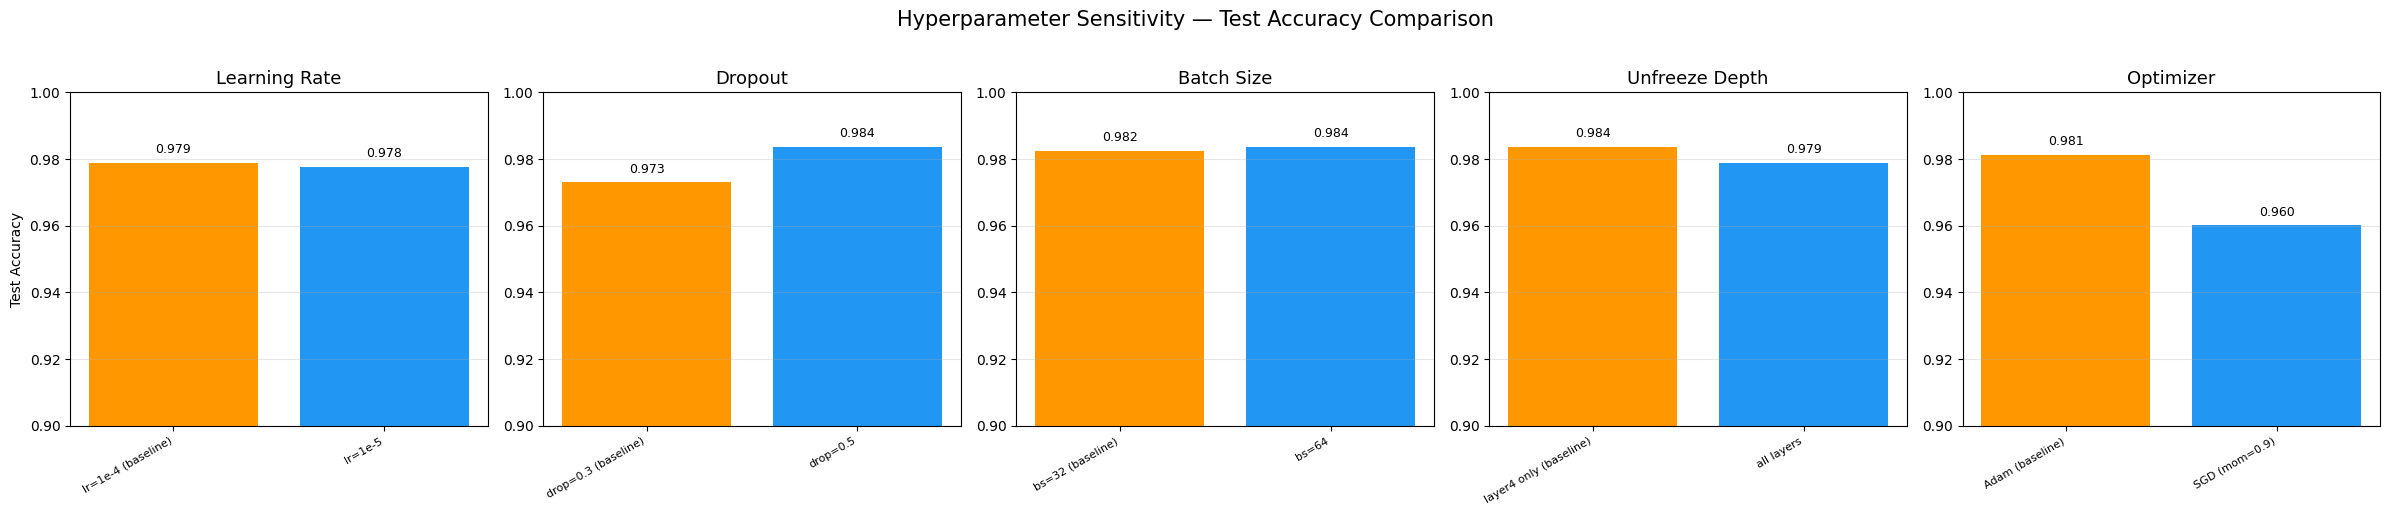

In [8]:
# Summary bar chart: test accuracy for every configuration
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for ax, (exp_name, runs) in zip(axes, results.items()):
    labels = [r[0] for r in runs]
    test_accs = [r[2] for r in runs]
    colors = ["#2196F3" if "(baseline)" not in l else "#FF9800" for l in labels]
    bars = ax.bar(range(len(labels)), test_accs, color=colors)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax.set_title(exp_name, fontsize=13)
    ax.set_ylim(0.90, 1.0)
    ax.grid(axis="y", alpha=0.3)
    for bar, acc in zip(bars, test_accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{acc:.3f}", ha="center", va="bottom", fontsize=9)

axes[0].set_ylabel("Test Accuracy")
plt.suptitle("Hyperparameter Sensitivity — Test Accuracy Comparison", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()